# Week3 (Regression) 과제
## Boston Housing Data 분석
### 데이터 소개
- **CRIM**: Per capita crime rate by town.
- **ZN**: Proportion of residential land zoned for lots over 25,000 square feet.
- **INDUS**: Proportion of non-retail business acres per town.
- **CHAS**: Charles River dummy variable (= 1 if tract bounds river; 0 otherwise).
- **NOX**: Nitric oxide concentration (parts per 10 million).
- **RM**: Average number of rooms per dwelling.
- **AGE**: Proportion of owner-occupied units built prior to 1940.
- **DIS**: Weighted distances to five Boston employment centers.
- **RAD**: Index of accessibility to radial highways.
- **TAX**: Full-value property tax rate per $10,000.
- **PTRATIO**: Pupil-teacher ratio by town.
- **B**: 1000(Bk - 0.63)^2 where Bk is the proportion of Black residents by town.
- **LSTAT**: Percentage of lower status of the population.

Target Variable:
- **MEDV**: Median value of owner-occupied homes in $1000s.

In [10]:
# 코랩 환경: 구글 드라이브를 코랩에 연동
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [12]:
PATH = '/content/drive/MyDrive/'
house = pd.read_excel(PATH + 'housing.xls')

# Q1: `head`, `info`, `describe`, `shape` 함수를 실행해봅시다.

* 데이터 앞부분 5행 확인
house.head()

* 컬럼명, 결측치, 데이터 타입 등 확인
house.info()
* 수치형 변수의 요약통계 확인
house.describe()

* 데이터의 행과 열 개수 확인
house.shape

# Q2: 각 변수의 결측치 (NaN 또는 Null)의 개수를 구해봅시다.

과제2 참고

In [13]:
# NaN의 개수 구하기
print(house.isnull().sum())




CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


# Q3: 각 변수별로 히스토그램을 그리고, Scatterplot Matrix를 그려봅시다

과제2 참고

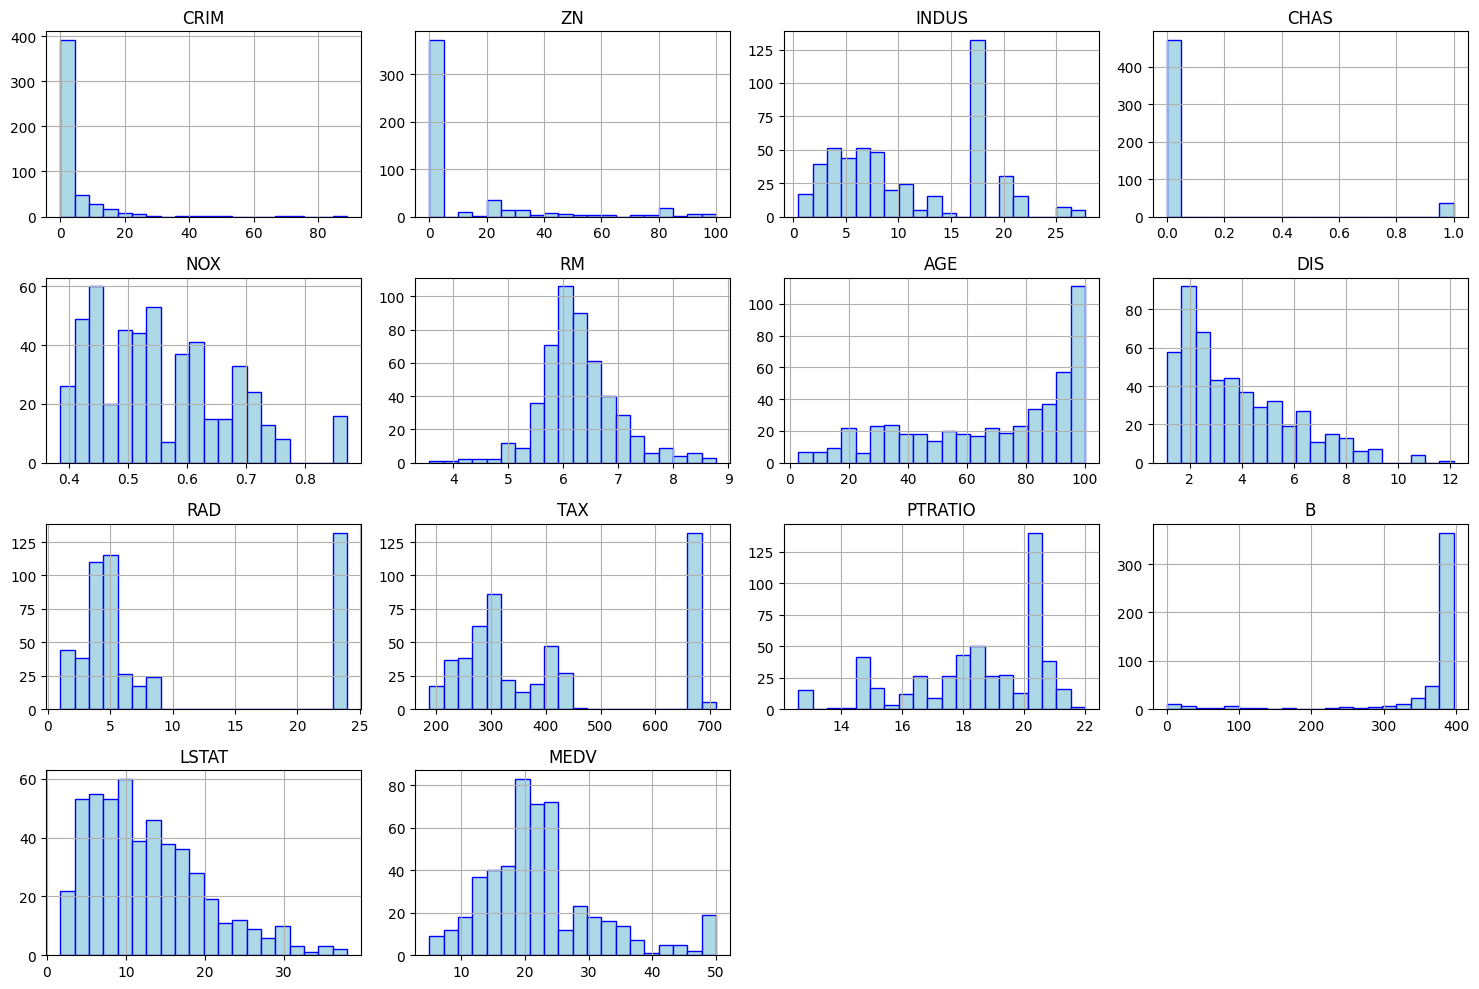

In [14]:
# Histogram
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix


# 1. 각 수치형 변수별 히스토그램
house.hist(figsize=(15, 10), color='lightblue', edgecolor='blue', bins=20)
plt.tight_layout()
plt.show()



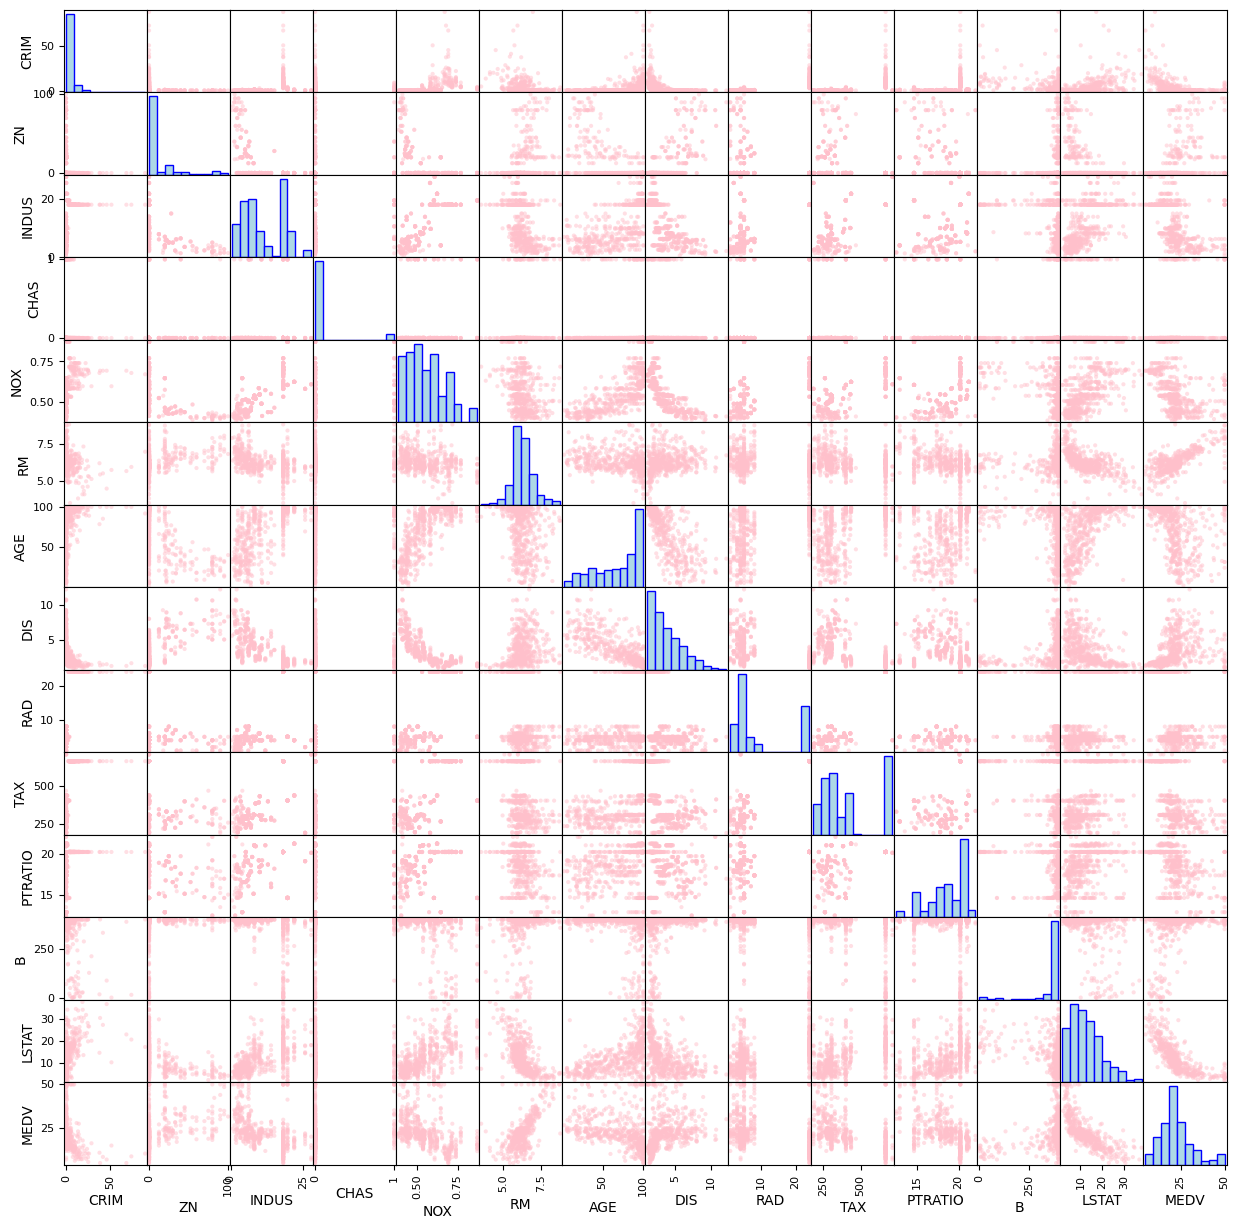

In [15]:
# Scatterplot Matrix
# 2. Scatterplot Matrix
scatter_matrix(
    house.select_dtypes(include='number'),
    figsize=(15, 15),
    diagonal='hist',
    alpha=0.5,
    color='pink',
    hist_kwds={
        'color': 'lightblue',
        'edgecolor': 'blue' }
)
plt.show()

## Q3-1. 다중공선성(multicolinearity)을 확인하기 위해 VIF를 추가로 확인해봅시다.

In [16]:
# 그대로 실행하기 !!
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
vif['VIF Factor'] = [variance_inflation_factor(house.values, i) for i in range(house.shape[1])]
vif['features'] = house.columns

# VIF가 높은 순서대로 정렬
vif = vif.sort_values(
    by='VIF Factor',
    ascending=False
).reset_index(drop=True)

vif

,VIF Factor,features
0,136.101743,RM
1,87.227233,PTRATIO
2,74.004269,NOX
3,61.939713,TAX
4,24.503206,MEDV
5,21.398863,AGE
6,21.351015,B
7,15.430455,DIS
8,15.369980,RAD
9,14.485874,INDUS


## Q3-2.
VIF가 높은 변수가 하나씩 줄어들면 다른 변수들의 VIF에도 영향을 미치기 때문에 변수들을 한 번에 다 제거하기보다는 하나씩 제거하면서 확인해 나아가는 것이 바람직합니다! 여러 차례 VIF를 확인해보면서 변수를 제거해보세요!

In [17]:
vif = pd.DataFrame()
x_data = house.drop( 'RM' ,axis=1)  # VIF가 높은순서대로 1개까지 제거
vif["VIF Factor"] = [variance_inflation_factor(x_data.values, i) for i in range(x_data.shape[1])]
vif["features"] = x_data.columns
# VIF가 높은 순서대로 정렬
vif = vif.sort_values(
    by='VIF Factor',
    ascending=False
).reset_index(drop=True)
vif

,VIF Factor,features
0,69.068505,PTRATIO
1,62.073615,NOX
2,61.603579,TAX
3,21.304461,B
4,20.752654,AGE
5,15.134503,RAD
6,14.258330,DIS
7,14.202832,INDUS
8,14.033493,MEDV
9,12.450745,LSTAT


In [18]:
vif = pd.DataFrame()
x_data = house.drop(['RM','PTRATIO'] ,axis=1)  # VIF가 높은순서대로 2개까지 제거
vif["VIF Factor"] = [variance_inflation_factor(x_data.values, i) for i in range(x_data.shape[1])]
vif["features"] = x_data.columns
# VIF가 높은 순서대로 정렬
vif = vif.sort_values(
    by='VIF Factor',
    ascending=False
).reset_index(drop=True)
vif

,VIF Factor,features
0,59.247225,NOX
1,58.759509,TAX
2,20.427509,AGE
3,19.222365,B
4,15.130157,RAD
5,14.147928,INDUS
6,13.431156,MEDV
7,12.012673,LSTAT
8,9.639018,DIS
9,2.558330,ZN


In [19]:
vif = pd.DataFrame()
x_data = house.drop(['RM','PTRATIO', 'NOX'] ,axis=1)  # VIF가 높은순서대로 3개까지 제거
vif["VIF Factor"] = [variance_inflation_factor(x_data.values, i) for i in range(x_data.shape[1])]
vif["features"] = x_data.columns
# VIF가 높은 순서대로 정렬
vif = vif.sort_values(
    by='VIF Factor',
    ascending=False
).reset_index(drop=True)
vif

,VIF Factor,features
0,54.753156,TAX
1,18.593595,B
2,17.056895,AGE
3,15.049247,RAD
4,13.152242,INDUS
5,11.446226,MEDV
6,11.031436,LSTAT
7,9.446150,DIS
8,2.548017,ZN
9,2.103346,CRIM


In [20]:
vif = pd.DataFrame()
x_data = house.drop(['RM','PTRATIO', 'NOX', 'TAX'] ,axis=1)  # VIF가 높은순서대로 4개까지 제거
vif["VIF Factor"] = [variance_inflation_factor(x_data.values, i) for i in range(x_data.shape[1])]
vif["features"] = x_data.columns
# VIF가 높은 순서대로 정렬
vif = vif.sort_values(
    by='VIF Factor',
    ascending=False
).reset_index(drop=True)
vif

,VIF Factor,features
0,18.131319,B
1,16.449470,AGE
2,11.385287,MEDV
3,10.934458,LSTAT
4,9.024818,INDUS
5,8.722321,DIS
6,4.858231,RAD
7,2.465535,ZN
8,2.103261,CRIM
9,1.142745,CHAS


In [21]:
vif = pd.DataFrame()
x_data = house.drop(['RM','PTRATIO', 'NOX', 'TAX', 'B'] ,axis=1) # VIF가 높은순서대로 5개까지 제거
vif["VIF Factor"] = [variance_inflation_factor(x_data.values, i) for i in range(x_data.shape[1])]
vif["features"] = x_data.columns
# VIF가 높은 순서대로 정렬
vif = vif.sort_values(
    by='VIF Factor',
    ascending=False
).reset_index(drop=True)
vif

,VIF Factor,features
0,15.731199,AGE
1,10.641862,LSTAT
2,8.855666,INDUS
3,8.500366,MEDV
4,6.518545,DIS
5,4.733212,RAD
6,2.421949,ZN
7,2.095925,CRIM
8,1.142321,CHAS


In [22]:
vif = pd.DataFrame()
x_data = house.drop(['RM','PTRATIO', 'NOX', 'TAX', 'B', 'AGE'] ,axis=1) # VIF가 높은순서대로 6개까지 제거
vif["VIF Factor"] = [variance_inflation_factor(x_data.values, i) for i in range(x_data.shape[1])]
vif["features"] = x_data.columns
# VIF가 높은 순서대로 정렬
vif = vif.sort_values(
    by='VIF Factor',
    ascending=False
).reset_index(drop=True)
vif

,VIF Factor,features
0,8.044685,INDUS
1,7.012987,LSTAT
2,6.395977,DIS
3,5.630097,MEDV
4,4.727054,RAD
5,2.317242,ZN
6,2.095110,CRIM
7,1.141690,CHAS


**다중공선성을 완화하기 위해 VIF가 높은 변수부터 총 6개를 순차적으로 제외하였으며, 최종적으로 모든 독립변수의 VIF가 10 이하로 나타났다.**

**house 데이터셋에 변수 제거를 적용하지 않고 우선 진행하세요! 추후에 MSE 비교를 통해 변수 제거를 확실히 해봅시다.**

# Q4: 데이터를 `X_train`, `X_test`, `y_train`, `y_test` 로 split해 봅시다

split 비율은 자유롭게 정해보시기 바랍니다.

In [23]:
# train_test_split

# 설명변수와 목표변수 분리
X = house.drop('MEDV', axis=1)
y = house['MEDV']

# 학습 데이터와 테스트 데이터를 8:2로 분리
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 분할 결과 확인
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (404, 13)
X_test shape: (102, 13)
y_train shape: (404,)
y_test shape: (102,)


MEDV가 보통 주택가격의 중앙값(Median Value)이라서, 이 데이터에서 예측하려는 종속변수 y일 가능성이 높다고 보았다. 따라서 예측 대상인 MEDV는 먼저 제외해보고자 하였다.

# Q5: `StandardScaler`로 표준화를 해봅시다

CRIM, ZN, INDUS, NOX, RM, AGE, DIS, TAX, PTRATIO, B, LSTAT 변수들만 `StandardScaler`을 해봅시다. (이들 중 다중공선성으로 인해 제거한 변수들이 있다면 제외하고 진행해주세요.)

`X_train`은 `fit_transform`, `X_test`는 `transform`을 이용하는 것에 유의합시다!

In [24]:
# StandardScaler
from sklearn.preprocessing import StandardScaler

# 표준화 대상 후보 변수
candidate_cols = [
    'CRIM', 'ZN', 'INDUS', 'NOX', 'RM',
    'AGE', 'DIS', 'TAX', 'PTRATIO', 'B', 'LSTAT'
]

# 다중공선성 제거 후 X_train에 실제로 남아 있는 변수만 선택
scale_cols = [
    col for col in candidate_cols
    if col in X_train.columns
]

# 원본 보존을 위한 복사본
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# 표준화 객체 생성
scaler = StandardScaler()

# 훈련 데이터: 평균·표준편차를 구한 뒤 표준화
X_train_scaled[scale_cols] = scaler.fit_transform(
    X_train_scaled[scale_cols]
)

# 테스트 데이터: 훈련 데이터에서 구한 기준으로 표준화만 수행
X_test_scaled[scale_cols] = scaler.transform(
    X_test_scaled[scale_cols]
)

print('표준화한 변수:', scale_cols)
display(X_train_scaled.head())

# 표준화가 잘 되었는지 확인
print("표준화된 학습 데이터 평균:")
print(X_train_scaled[scale_cols].mean().round(3))

print("\n표준화된 학습 데이터 표준편차:")
print(X_train_scaled[scale_cols].std(ddof=0).round(3))


표준화한 변수: ['CRIM', 'ZN', 'INDUS', 'NOX', 'RM', 'AGE', 'DIS', 'TAX', 'PTRATIO', 'B', 'LSTAT']


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
477,1.287702,-0.500320,1.033237,0,0.489252,-1.428069,1.028015,-0.802173,24,1.578434,0.845343,-0.074337,1.753505
15,-0.336384,-0.500320,-0.413160,0,-0.157233,-0.680087,-0.431199,0.324349,4,-0.584648,1.204741,0.430184,-0.561474
332,-0.403253,1.013271,-0.715218,0,-1.008723,-0.402063,-1.618599,1.330697,1,-0.602724,-0.637176,0.065297,-0.651595
423,0.388230,-0.500320,1.033237,0,0.489252,-0.300450,0.591681,-0.839240,24,1.578434,0.845343,-3.868193,1.525387
19,-0.325282,-0.500320,-0.413160,0,-0.157233,-0.831094,0.033747,-0.005494,4,-0.584648,1.204741,0.379119,-0.165787


표준화된 학습 데이터 평균:
CRIM      -0.0
ZN         0.0
INDUS     -0.0
NOX       -0.0
RM        -0.0
AGE       -0.0
DIS        0.0
TAX       -0.0
PTRATIO    0.0
B         -0.0
LSTAT     -0.0
dtype: float64

표준화된 학습 데이터 표준편차:
CRIM       1.0
ZN         1.0
INDUS      1.0
NOX        1.0
RM         1.0
AGE        1.0
DIS        1.0
TAX        1.0
PTRATIO    1.0
B          1.0
LSTAT      1.0
dtype: float64


# Q6: 5-fold Cross-Validation으로 `LinearRegression`을 적합해봅시다.

각 fold마다 적합 후 MSE, MAE, RMSE, $R^2$를 구하고, coefficient과 intercept를 `print` 해보세요.

In [34]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# 5-fold 설정
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 결과 저장용 리스트
metrics_results = []
coef_results = []

# fold별 학습 및 검증
for fold, (train_idx, valid_idx) in enumerate(
    kf.split(X_train_scaled),
    start=1
):
    X_fold_train = X_train_scaled.iloc[train_idx]
    X_fold_valid = X_train_scaled.iloc[valid_idx]

    y_fold_train = y_train.iloc[train_idx]
    y_fold_valid = y_train.iloc[valid_idx]

    # 모델 학습
    model = LinearRegression()
    model.fit(X_fold_train, y_fold_train)

    # 예측
    y_pred = model.predict(X_fold_valid)

    # 평가 지표 계산
    mse = mean_squared_error(y_fold_valid, y_pred)
    mae = mean_absolute_error(y_fold_valid, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_fold_valid, y_pred)

    # fold별 성능 저장
    metrics_results.append({
        'Fold': fold,
        'MSE': mse,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
        'Intercept': model.intercept_
    })

    # fold별 계수 저장
    coef_row = {'Fold': fold}

    for feature, coef in zip(
        X_train_scaled.columns,
        model.coef_
    ):
        coef_row[feature] = coef

    coef_results.append(coef_row)

# DataFrame 생성
metrics_df = pd.DataFrame(metrics_results)
coef_df = pd.DataFrame(coef_results)

# 소수점 정리
metrics_df = metrics_df.round(4)
coef_df = coef_df.round(4)

print("Fold별 성능 지표")
display(metrics_df)

print("Fold별 회귀계수")
display(coef_df)

mean_row = {
    'Fold': 'Mean',
    'MSE': metrics_df['MSE'].mean(),
    'MAE': metrics_df['MAE'].mean(),
    'RMSE': metrics_df['RMSE'].mean(),
    'R2': metrics_df['R2'].mean(),
    'Intercept': metrics_df['Intercept'].mean()
}

metrics_df_with_mean = pd.concat(
    [metrics_df, pd.DataFrame([mean_row])],
    ignore_index=True
)

display(metrics_df_with_mean.round(4))

Fold별 성능 지표


,Fold,MSE,MAE,RMSE,R2,Intercept
0,1,23.2864,3.2108,4.8256,0.6725,20.5048
1,2,23.5646,3.4965,4.8543,0.7601,20.1013
2,3,36.4745,3.7736,6.0394,0.5895,20.5784
3,4,25.7558,3.9217,5.0750,0.7592,19.8610
4,5,12.5105,2.7395,3.5370,0.8112,19.6980


Fold별 회귀계수


,Fold,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,1,-0.9481,0.7586,0.3009,3.0076,-2.2275,3.5129,-0.0702,-3.2193,0.2202,-1.4567,-2.0815,1.1573,-3.2812
1,2,-1.0581,0.7422,0.1049,3.0930,-2.0143,2.7999,-0.1748,-3.3261,0.2430,-1.7421,-1.7766,1.0934,-3.9721
2,3,-0.8396,0.6840,0.5637,0.6283,-1.6412,3.4941,-0.3119,-2.6510,0.2250,-2.0508,-2.1805,1.2383,-2.9970
3,4,-1.0337,0.3269,-0.0331,4.6142,-1.9962,2.9200,-0.2925,-2.8870,0.2852,-1.4279,-2.1351,1.0205,-3.9890
4,5,-1.0966,0.8967,0.4574,2.5334,-2.2169,3.0900,-0.0464,-3.2372,0.3314,-2.2369,-2.0919,1.1487,-3.5907


,Fold,MSE,MAE,RMSE,R2,Intercept
0,1,23.2864,3.2108,4.8256,0.6725,20.5048
1,2,23.5646,3.4965,4.8543,0.7601,20.1013
2,3,36.4745,3.7736,6.0394,0.5895,20.5784
3,4,25.7558,3.9217,5.0750,0.7592,19.8610
4,5,12.5105,2.7395,3.5370,0.8112,19.6980
5,Mean,24.3184,3.4284,4.8663,0.7185,20.1487


### Q6-1: 다중공선성이 높았던 변수를 제거한 후 다시 train_test_split, scaler, 5-fold CV 과정으로 `LinearRegression`을 적합한 후 Q6에서 구한 평균 MSE(or MAE, RMSE, $R^2$)와 비교해보세요.

In [35]:
# 다중공선성이 높은 변수 목록
removed_cols = ['RM', 'PTRATIO', 'NOX', 'TAX', 'B', 'AGE']

# 목표변수 MEDV를 제외한 원본 설명변수
X_original = house.drop(columns=['MEDV'])

# 다중공선성 변수 제거 후 설명변수
house_new = X_original.drop(columns=removed_cols)

# 목표변수
y = house['MEDV']

print("제거한 변수:", removed_cols)
print("남은 변수:", house_new.columns.tolist())

제거한 변수: ['RM', 'PTRATIO', 'NOX', 'TAX', 'B', 'AGE']
남은 변수: ['CRIM', 'ZN', 'INDUS', 'CHAS', 'DIS', 'RAD', 'LSTAT']


In [37]:
import numpy as np
import pandas as pd

from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_validate
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

# train_test_split

X_train_reduced, X_test_reduced, y_train_reduced, y_test_reduced = (
    train_test_split(
        house_new,
        y,
        test_size=0.2,
        random_state=42
    )
)

print("학습 데이터:", X_train_reduced.shape)
print("테스트 데이터:", X_test_reduced.shape)


# StandardScaler

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

# KFold, cross_val_score, cross_validation 이용


kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    'MSE': 'neg_mean_squared_error',
    'MAE': 'neg_mean_absolute_error',
    'R2': 'r2'
}

cv_result_reduced = cross_validate(
    pipeline,
    X_train_reduced,
    y_train_reduced,
    cv=kf,
    scoring=scoring
)

# 제거 후 fold별 평가 결과 정리
reduced_metrics_df = pd.DataFrame({
    'Fold': range(1, 6),
    'MSE': -cv_result_reduced['test_MSE'],
    'MAE': -cv_result_reduced['test_MAE'],
    'RMSE': np.sqrt(-cv_result_reduced['test_MSE']),
    'R2': cv_result_reduced['test_R2']
})

print("다중공선성 변수 제거 후 Fold별 성능")
display(reduced_metrics_df.round(4))

# 제거 후 평균 성능
reduced_mean_df = pd.DataFrame({
    'Metric': ['MSE', 'MAE', 'RMSE', 'R2'],
    '제거 후 평균': [
        reduced_metrics_df['MSE'].mean(),
        reduced_metrics_df['MAE'].mean(),
        reduced_metrics_df['RMSE'].mean(),
        reduced_metrics_df['R2'].mean()
    ]
})

print("다중공선성 변수 제거 후 평균 성능")
display(reduced_mean_df.round(4))

# Q6 제거 전 평균과 Q6-1 제거 후 평균 비교
comparison_df = pd.DataFrame({
    'Metric': ['MSE', 'MAE', 'RMSE', 'R2'],

    '제거 전 평균(Q6)': [
        metrics_df['MSE'].mean(),
        metrics_df['MAE'].mean(),
        metrics_df['RMSE'].mean(),
        metrics_df['R2'].mean()
    ],

    '제거 후 평균(Q6-1)': [
        reduced_metrics_df['MSE'].mean(),
        reduced_metrics_df['MAE'].mean(),
        reduced_metrics_df['RMSE'].mean(),
        reduced_metrics_df['R2'].mean()
    ]
})

comparison_df['변화량(제거 후 - 제거 전)'] = (
    comparison_df['제거 후 평균(Q6-1)']
    - comparison_df['제거 전 평균(Q6)']
)

print("다중공선성 변수 제거 전후 성능 비교")
display(comparison_df.round(4))


학습 데이터: (404, 7)
테스트 데이터: (102, 7)
다중공선성 변수 제거 후 Fold별 성능


,Fold,MSE,MAE,RMSE,R2
0,1,24.8317,3.7680,4.9831,0.6507
1,2,41.4869,4.4288,6.4410,0.5776
2,3,39.4284,4.5579,6.2792,0.5562
3,4,39.9305,4.7700,6.3191,0.6266
4,5,22.6450,3.7683,4.7587,0.6583


다중공선성 변수 제거 후 평균 성능


,Metric,제거 후 평균
0,MSE,33.6645
1,MAE,4.2586
2,RMSE,5.7562
3,R2,0.6139


다중공선성 변수 제거 전후 성능 비교


,Metric,제거 전 평균(Q6),제거 후 평균(Q6-1),변화량(제거 후 - 제거 전)
0,MSE,24.3184,33.6645,9.3461
1,MAE,3.4284,4.2586,0.8302
2,RMSE,4.8663,5.7562,0.8900
3,R2,0.7185,0.6139,-0.1046



* 다중공선성이 높은 변수인 RM, PTRATIO, NOX, TAX, B, AGE를 제거한 후 동일한 조건으로 5-fold cross-validation을 수행하였다.
* 제거 전 평균 MSE, MAE, RMSE는 각각 24.3184, 3.4284, 4.8663이었으며, 제거 후에는 각각 33.6645, 4.2586, 5.7562로 증가하였다.
* 또한 평균 R²는 0.7185에서 0.6139로 감소하였다.
* 따라서 다중공선성은 완화되었으나, 주요 예측변수의 제거로 인해 모델의 예측 성능은 전반적으로 저하된 것으로 판단된다.


# Q7(Optional): `GridSearchCV`를 이용하여 `Lasso`를 적합해봅시다.

찾아야 하는 최적 파라미터는

- `alpha`: 0.01, 0.1, 1, 10 중에서 찾기
- `fit_intercept`: `True`, `False`에서 찾기

https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-parameter

위 링크를 참조하여 `GridSearCV`의 `scoring`을 3가지 이상 사용해보세요

In [38]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso

# param_grid

import numpy as np
import pandas as pd

from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, GridSearchCV

# StandardScaler + Lasso
lasso_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(max_iter=10000))
])

# 탐색할 파라미터
param_grid = {
    'lasso__alpha': [0.01, 0.1, 1, 10],
    'lasso__fit_intercept': [True, False]
}

# 5-fold
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# scoring 4가지
scoring = {
    'MSE': 'neg_mean_squared_error',
    'MAE': 'neg_mean_absolute_error',
    'RMSE': 'neg_root_mean_squared_error',
    'R2': 'r2'
}

# GridSearchCV
grid_search = GridSearchCV(
    estimator=lasso_pipeline,
    param_grid=param_grid,
    scoring=scoring,
    refit='R2',
    cv=kf,
    return_train_score=True,
    n_jobs=-1
)

# 학습
grid_search.fit(
    X_train_reduced,
    y_train_reduced
)

print("최적 파라미터:", grid_search.best_params_)
print("최적 평균 CV R2:", round(grid_search.best_score_, 4))

# 전체 조합 결과
grid_results_df = pd.DataFrame(
    grid_search.cv_results_
)

grid_results_df = grid_results_df[[
    'param_lasso__alpha',
    'param_lasso__fit_intercept',
    'mean_test_MSE',
    'mean_test_MAE',
    'mean_test_RMSE',
    'mean_test_R2',
    'rank_test_R2'
]].copy()

# 음수 scoring을 양수 오차로 변환
grid_results_df['mean_test_MSE'] *= -1
grid_results_df['mean_test_MAE'] *= -1
grid_results_df['mean_test_RMSE'] *= -1

# 열 이름 변경
grid_results_df = grid_results_df.rename(columns={
    'param_lasso__alpha': 'alpha',
    'param_lasso__fit_intercept': 'fit_intercept',
    'mean_test_MSE': '평균 MSE',
    'mean_test_MAE': '평균 MAE',
    'mean_test_RMSE': '평균 RMSE',
    'mean_test_R2': '평균 R2',
    'rank_test_R2': 'R2 순위'
})

grid_results_df = grid_results_df.sort_values(
    by='평균 R2',
    ascending=False
).reset_index(drop=True)

display(grid_results_df.round(4))

# 최적 모델의 계수
best_lasso_model = (
    grid_search
    .best_estimator_
    .named_steps['lasso']
)

coef_df = pd.DataFrame({
    'Variable': X_train_reduced.columns,
    'Coefficient': best_lasso_model.coef_
})

print("최적 Lasso 회귀계수")
display(coef_df.round(4))


최적 파라미터: {'lasso__alpha': 0.1, 'lasso__fit_intercept': True}
최적 평균 CV R2: 0.6174


,alpha,fit_intercept,평균 MSE,평균 MAE,평균 RMSE,평균 R2,R2 순위
0,0.10,True,33.5203,4.2298,5.7330,0.6174,1
1,0.01,True,33.6285,4.2544,5.7520,0.6145,2
2,1.00,True,40.4975,4.5882,6.2984,0.5387,3
3,10.00,True,87.1342,6.8189,9.2972,-0.0106,4
4,0.10,False,554.4251,22.8263,23.5406,-5.6035,5
5,1.00,False,558.9801,22.7765,23.6264,-5.6139,6
6,0.01,False,555.0296,22.8367,23.5542,-5.6178,7
7,10.00,False,606.3778,22.7937,24.6058,-6.1740,8


최적 Lasso 회귀계수


,Variable,Coefficient
0,CRIM,-1.0110
1,ZN,1.4485
2,INDUS,-1.7309
3,CHAS,1.0188
4,DIS,-3.2781
5,RAD,-0.0182
6,LSTAT,-6.2676


**1. 최적 파라미터**
GridSearchCV를 이용하여 alpha와 fit_intercept의 조합을 탐색한 결과, alpha=0.1, fit_intercept=True일 때 평균 교차검증 R²가 0.6174로 가장 높았다.

**2. fit_intercept=True가 압도적으로 좋은 이유**
목표변수 MEDV는 평균이 0이 아닌데 절편을 강제로 0으로 두면, 회귀식이 원점을 통과해야 해서 예측이 크게 왜곡되기 때문이다. 따라서 이 데이터에서는 절편을 포함하는 것이 필수적이다.

**3. 최적 alpha**

 alpha=0.1 정도의 약한 규제가 가장 적절했고, alpha=10은 계수를 지나치게 줄여 성능이 크게 나빠졌다.

**4. Q6-1 LinearRegression과 비교**
* 이 조합의 평균 MSE, MAE, RMSE는 각각 33.5203, 4.2298, 5.7330으로 나타났다.
* MSE: 33.6645 → 33.5203 감소
* MAE: 4.2586 → 4.2298 감소
* RMSE: 5.7562 → 5.7330 감소
* R²: 0.6139 → 0.6174 증가
* 변수 제거 후 일반 선형회귀와 비교하면 Lasso의 오차 지표는 소폭 감소하고 R²는 소폭 증가하여 예측 성능이 약간 개선되었다.
* 또한 alpha가 지나치게 커질 경우 과도한 규제로 인해 성능이 크게 저하되는 것을 확인하였다.

**5. 회귀계수 해석**

* LSTAT = -6.2676,
DIS   = -3.2781

 이므로 표준화된 조건에서 LSTAT가 증가할수록 MEDV가 크게 감소하는 방향이고, DIS도 음의 영향을 보였다.
* RAD 계수는 -0.0182로 거의 0에 가까운데 완전히 0은 아니다. 따라서 이번 최적 Lasso는 변수를 완전히 제거하지는 않았고, 일부 계수만 강하게 축소한 결과로 보인다.

# Q8(Optional): `RandomizedSearchCV`를 이용하여 `Ridge`를 적합해 봅시다.

CV를 이용한 hyperparameter tuning의 또다른 방법은 `RandomizedSearchCV`입니다.
Tuning해야 하는 모수가 많을 경우 이 방법이 빠르다는 장점이 있습니다.

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html#

위 링크를 참조하거나 구글링을 하여 `Ridge`를 적합해보세요.

`n_iter`와, 파라미터 공간을 자유롭게 조정해보세요.

In [39]:
import numpy as np
import pandas as pd

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    KFold,
    RandomizedSearchCV
)

# 1. StandardScaler + Ridge
ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

# 2. 탐색할 파라미터 공간
param_distributions = {
    'ridge__alpha': np.logspace(-3, 3, 100),
    'ridge__fit_intercept': [True, False],
    'ridge__solver': [
        'auto',
        'svd',
        'cholesky',
        'lsqr'
    ]
}

# 3. 5-fold 설정
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# 4. 평가 지표 4개
scoring = {
    'MSE': 'neg_mean_squared_error',
    'MAE': 'neg_mean_absolute_error',
    'RMSE': 'neg_root_mean_squared_error',
    'R2': 'r2'
}

# 5. RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=ridge_pipeline,
    param_distributions=param_distributions,
    n_iter=30,
    scoring=scoring,
    refit='R2',
    cv=kf,
    random_state=42,
    n_jobs=-1,
    return_train_score=True
)

# 6. 모델 적합
random_search.fit(
    X_train_reduced,
    y_train_reduced
)

# 7. 최적 파라미터와 점수 출력
print("최적 파라미터:", random_search.best_params_)
print(
    "최적 평균 CV R2:",
    round(random_search.best_score_, 4)
)

최적 파라미터: {'ridge__solver': 'cholesky', 'ridge__fit_intercept': True, 'ridge__alpha': np.float64(4.9770235643321135)}
최적 평균 CV R2: 0.6146


In [40]:
# RandomizedSearchCV 전체 결과
ridge_results_df = pd.DataFrame(
    random_search.cv_results_
)

# 필요한 열만 선택
ridge_results_df = ridge_results_df[[
    'param_ridge__alpha',
    'param_ridge__fit_intercept',
    'param_ridge__solver',
    'mean_test_MSE',
    'mean_test_MAE',
    'mean_test_RMSE',
    'mean_test_R2',
    'rank_test_R2'
]].copy()

# 음수 scoring을 양수 오차로 변환
ridge_results_df['mean_test_MSE'] *= -1
ridge_results_df['mean_test_MAE'] *= -1
ridge_results_df['mean_test_RMSE'] *= -1

# 열 이름 정리
ridge_results_df = ridge_results_df.rename(columns={
    'param_ridge__alpha': 'alpha',
    'param_ridge__fit_intercept': 'fit_intercept',
    'param_ridge__solver': 'solver',
    'mean_test_MSE': '평균 MSE',
    'mean_test_MAE': '평균 MAE',
    'mean_test_RMSE': '평균 RMSE',
    'mean_test_R2': '평균 R2',
    'rank_test_R2': 'R2 순위'
})

# R2가 높은 순서대로 정렬
ridge_results_df = ridge_results_df.sort_values(
    by='평균 R2',
    ascending=False
).reset_index(drop=True)

display(ridge_results_df.round(4))

,alpha,fit_intercept,solver,평균 MSE,평균 MAE,평균 RMSE,평균 R2,R2 순위
0,4.9770,True,cholesky,33.6533,4.2505,5.7520,0.6146,1
1,10.0000,True,svd,33.7037,4.2456,5.7533,0.6146,2
2,2.8480,True,auto,33.6496,4.2535,5.7530,0.6144,3
3,0.9326,True,lsqr,33.6570,4.2567,5.7549,0.6141,4
4,0.7055,True,svd,33.6585,4.2571,5.7552,0.6141,5
5,0.5337,True,auto,33.6599,4.2575,5.7554,0.6140,6
6,0.4037,True,cholesky,33.6609,4.2578,5.7556,0.6140,7
7,0.0031,True,svd,33.6645,4.2586,5.7562,0.6139,8
8,0.0031,True,cholesky,33.6645,4.2586,5.7562,0.6139,9
9,0.0031,True,lsqr,33.6645,4.2586,5.7562,0.6139,10



**Lasso: 0.6174**

**Ridge: 0.6146**

**LinearRegression: 0.6139**

* RandomizedSearchCV를 통해 Ridge의 하이퍼파라미터를 탐색한 결과, solver가 cholesky이고 fit_intercept가 True이며 alpha가 약 4.977일 때 평균 교차검증 R²가 0.6146으로 가장 높게 나타났다.
* 이는 일반 선형회귀의 평균 R² 0.6139보다 소폭 높지만 차이는 매우 작았으며, Lasso의 평균 R² 0.6174보다는 다소 낮았다.

**왜 fit_intercept=True인가?**
* Lasso 때와 마찬가지로 MEDV의 평균은 0이 아니기 때문에 절편을 포함해야 모델이 데이터의 기본적인 평균 수준을 반영할 수 있다.
* False로 설정하면 회귀식이 원점을 지나야 해서 성능이 크게 악화될 가능성이 높다.

**alpha=4.977의 의미**
* Ridge의 alpha는 L2 규제 강도로서, alpha가 커질수록 회귀계수가 더 강하게 축소되지만, Lasso처럼 일반적으로 계수를 정확히 0으로 만들지는 않는다.
* alpha = 4.9770, fit_intercept = True, solver = 'cholesky' 일때 최적 조합이고, 이때 평균 5-fold CV R²가 0.6146이다. 즉 해당 Ridge 모델이 검증 데이터의 주택가격 변동을 평균적으로 약 61.46% 설명했다고 해석할 수 있다.

